# REG Engineering & Related Tech

## Research context

Engineering & Related Tech (CategoryKey = 3) is a **priority field** under JRG. It received a
**fee reduction** in 2021, moving to a lower-cost funding cluster:

| Period | Student contribution (avg) | Commonwealth contribution (avg) |
|--------|---------------------------|----------------------------------|
| 2019   | $9,359                     | $18,586                          |
| 2021+  | $7,950 (−16 %)             | $16,250 (−14 %)                  |

Unlike Education (where both student and commonwealth contributions moved in opposite directions),
Engineering saw **both** student and commonwealth contributions fall under JRG. Total funding per
student declined. The expected demand effect is ambiguous: lower student fees incentivise enrolment,
but reduced commonwealth support may signal lower institutional capacity or prestige for the field.

AUS Engineering dipped in 2021–22 (118,229 → 109,812) before recovering strongly to 122,954 by
2024. UK Engineering grew through 2022 then declined. The DiD tests whether AUS deviated
*differentially* from the UK trend after 2021.

### Identifying strategy (country-level DiD)

$$\log(\text{Enrolments}_{ct}) = \alpha_c + \gamma_t + \beta(\text{AUS}_c \times \text{Post}_t) + \varepsilon_{ct}$$

where $c \in \{\text{AUS, UK}\}$, $\text{Post}_t = \mathbf{1}[t \geq 2021]$, and $\beta$ is the JRG effect for Engineering.

**Data window:** AUS 2016–2024 (9 years); UK 2016–2024 (9 years, start-year mapping: 2016/17 → 2016).
Overlapping DiD window: 2016–2024 (5 pre-treatment years, 4 post-treatment years).

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from linearmodels.panel import PanelOLS
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

START = Path.cwd()
ROOT = START
while ROOT != ROOT.parent and not (ROOT / 'data').exists():
    ROOT = ROOT.parent

AUS_PATH  = ROOT / 'data' / 'clean' / 'EnrollmentsAUS_category_with_numeric_key.csv'
UK_PATH   = ROOT / 'data' / 'clean' / 'uk_grouped' / 'with_categorykey' / 'UK_enrollments_grouped_comparison_all_years_with_categorykey.csv'
FUND_PATH = ROOT / 'data' / 'clean' / 'AnnualFundingAUS2019-2026_with_category_key.csv'

assert AUS_PATH.exists(),  f'Missing: {AUS_PATH}'
assert UK_PATH.exists(),   f'Missing: {UK_PATH}'
assert FUND_PATH.exists(), f'Missing: {FUND_PATH}'
print('Project root:', ROOT)
print('All data files found.')

Project root: C:\Users\neddp\ECC3479-Project-JRGS
All data files found.


## 1. AUS Descriptive Analysis

Examine Australia-only Engineering & Related Tech data (2016–2024) to characterise the enrolment
trend and test a simple pre/post break. AUS-only OLS uses a log-linear specification with HC3
robust SEs.

AUS Engineering & Related Tech -- enrolment data:


,year,enrollments,log_enrollments
0,2016,111060,11.617826
1,2017,115231,11.654694
2,2018,119909,11.694488
3,2019,121980,11.711612
4,2020,118229,11.680379
5,2021,112931,11.634532
6,2022,109812,11.606525
7,2023,115197,11.654399
8,2024,122954,11.719566


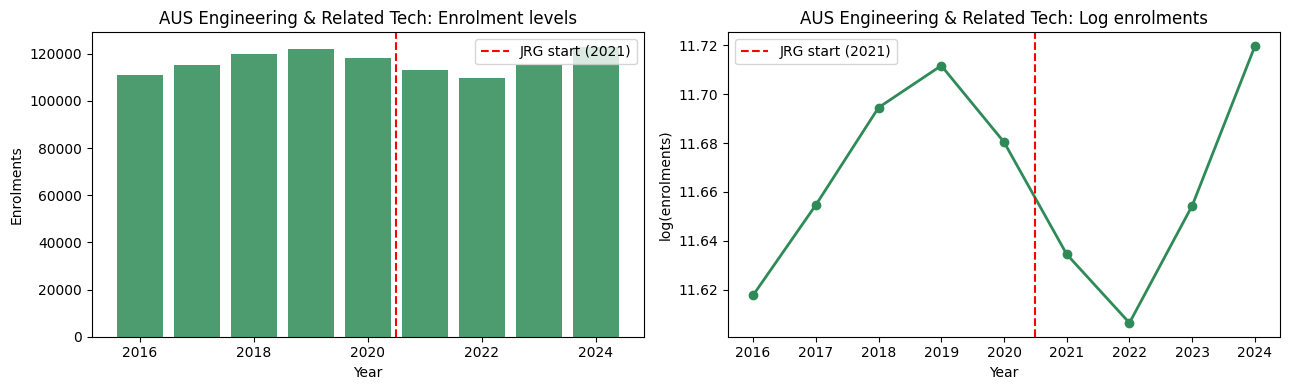

In [2]:
aus_raw   = pd.read_csv(AUS_PATH)
year_cols = [c for c in aus_raw.columns if str(c).isdigit()]

aus_long = aus_raw.melt(
    id_vars=['Category', 'CategoryKey'],
    value_vars=year_cols,
    var_name='year',
    value_name='enrollments',
)
aus_long['year']        = aus_long['year'].astype(int)
aus_long['enrollments'] = pd.to_numeric(aus_long['enrollments'], errors='coerce')

arch_aus = aus_long[aus_long['CategoryKey'] == 3].copy().sort_values('year').reset_index(drop=True)
arch_aus['log_enrollments'] = np.log(arch_aus['enrollments'])
arch_aus['year_c']   = arch_aus['year'] - 2019
arch_aus['year_c2']  = arch_aus['year_c'] ** 2
arch_aus['post_jrg'] = (arch_aus['year'] >= 2021).astype(int)

print('AUS Engineering & Related Tech -- enrolment data:')
display(arch_aus[['year', 'enrollments', 'log_enrollments']].reset_index(drop=True))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(arch_aus['year'], arch_aus['enrollments'], color='seagreen', alpha=0.85)
axes[0].axvline(2020.5, linestyle='--', color='red', linewidth=1.5, label='JRG start (2021)')
axes[0].set_title('AUS Engineering & Related Tech: Enrolment levels')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Enrolments'); axes[0].legend()

axes[1].plot(arch_aus['year'], arch_aus['log_enrollments'], 'o-', color='seagreen', linewidth=2)
axes[1].axvline(2020.5, linestyle='--', color='red', linewidth=1.5, label='JRG start (2021)')
axes[1].set_title('AUS Engineering & Related Tech: Log enrolments')
axes[1].set_xlabel('Year'); axes[1].set_ylabel('log(enrolments)'); axes[1].legend()

plt.tight_layout()
plt.show()

In [3]:
def summary_table(result, vars_):
    ci = result.conf_int()
    rows = []
    for v in vars_:
        if v not in result.params.index:
            continue
        rows.append({
            'Variable': v,
            'beta':     round(result.params[v], 4),
            'SE (HC3)': round(result.bse[v], 4),
            'p':        round(result.pvalues[v], 4),
            'CI lo':    round(ci.loc[v, 0], 4),
            'CI hi':    round(ci.loc[v, 1], 4),
        })
    out = pd.DataFrame(rows).set_index('Variable')
    display(out)
    print(f'R^2 = {result.rsquared:.4f} | Adj. R^2 = {result.rsquared_adj:.4f} | N = {int(result.nobs)}')

m_linear = smf.ols('log_enrollments ~ post_jrg + year_c',           data=arch_aus).fit(cov_type='HC3')
m_quad   = smf.ols('log_enrollments ~ post_jrg + year_c + year_c2', data=arch_aus).fit(cov_type='HC3')

print('=== AUS-only OLS: linear time trend ===')
summary_table(m_linear, ['Intercept', 'post_jrg', 'year_c'])
b_aus = m_linear.params['post_jrg']
print(f'\npost_jrg: ~{b_aus*100:.2f}% change in AUS enrolments post-JRG (controlling for linear trend)')

print('\n=== AUS-only OLS: quadratic time trend ===')
summary_table(m_quad, ['Intercept', 'post_jrg', 'year_c', 'year_c2'])

=== AUS-only OLS: linear time trend ===


,beta,SE (HC3),p,CI lo,CI hi
Variable,,,,,
Intercept,11.6940,0.0248,0.0000,11.6454,11.7427
post_jrg,-0.1181,0.0625,0.0587,-0.2406,0.0044
year_c,0.0222,0.0113,0.0482,0.0002,0.0443


R^2 = 0.6244 | Adj. R^2 = 0.4992 | N = 9

post_jrg: ~-11.81% change in AUS enrolments post-JRG (controlling for linear trend)

=== AUS-only OLS: quadratic time trend ===


,beta,SE (HC3),p,CI lo,CI hi
Variable,,,,,
Intercept,11.6899,0.0291,0.0000,11.6329,11.7469
post_jrg,-0.1243,0.0842,0.1399,-0.2893,0.0407
year_c,0.0212,0.0155,0.1704,-0.0091,0.0515
year_c2,0.0010,0.0040,0.7966,-0.0068,0.0089


R^2 = 0.6479 | Adj. R^2 = 0.4367 | N = 9


## 2. DiD Panel Construction

Combine AUS and UK Engineering & Related Tech data into a country x year panel (2019-2024).

**UK year mapping:** start-year rule -- 2019/20 -> 2019, 2020/21 -> 2020, etc.

**Treatment indicators:**
- `treated = 1` for AUS, `0` for UK
- `post = 1` for 2021+
- `did = treated x post` (main DiD interaction)
- `treated_covid2020`, `treated_covid2021`: AUS-specific COVID shock controls (kept for reference;
  note that adding these reduces df from 4 to 2, making inference unreliable -- see Section 3)

In [4]:
uk_raw  = pd.read_csv(UK_PATH)
arch_uk = uk_raw[uk_raw['categorykey'] == 3].copy()

arch_uk['year'] = arch_uk['AcademicYear'].str[:4].astype(int)
arch_uk = arch_uk[['year', 'Total UK']].rename(columns={'Total UK': 'enrollments'})
arch_uk['enrollments'] = pd.to_numeric(arch_uk['enrollments'], errors='coerce')
arch_uk['country'] = 'UK'

arch_aus_did = arch_aus[arch_aus['year'] >= 2016][['year', 'enrollments']].copy()
arch_aus_did['country'] = 'AUS'

panel = pd.concat([arch_aus_did, arch_uk], ignore_index=True).sort_values(['country', 'year']).reset_index(drop=True)
panel['log_enrollments']   = np.log(panel['enrollments'])
panel['treated']           = (panel['country'] == 'AUS').astype(int)
panel['post']              = (panel['year'] >= 2021).astype(int)
panel['did']               = panel['treated'] * panel['post']
panel['covid_2020']        = (panel['year'] == 2020).astype(int)
panel['covid_2021']        = (panel['year'] == 2021).astype(int)
panel['treated_covid2020'] = panel['treated'] * panel['covid_2020']
panel['treated_covid2021'] = panel['treated'] * panel['covid_2021']
panel['year_c']            = panel['year'] - 2020

print('DiD panel -- Engineering & Related Tech (AUS vs UK):')
display(panel[['country','year','enrollments','log_enrollments','treated','post','did']].reset_index(drop=True))
print(f'\nShape: {panel.shape} | Pre-treatment: {sorted(panel[panel["post"]==0]["year"].unique())} | Post: {sorted(panel[panel["post"]==1]["year"].unique())}')

DiD panel -- Engineering & Related Tech (AUS vs UK):


,country,year,enrollments,log_enrollments,treated,post,did
0,AUS,2016,111060.0,11.617826,1,0,0
1,AUS,2017,115231.0,11.654694,1,0,0
2,AUS,2018,119909.0,11.694488,1,0,0
3,AUS,2019,121980.0,11.711612,1,0,0
4,AUS,2020,118229.0,11.680379,1,0,0
5,AUS,2021,112931.0,11.634532,1,1,1
6,AUS,2022,109812.0,11.606525,1,1,1
7,AUS,2023,115197.0,11.654399,1,1,1
8,AUS,2024,122954.0,11.719566,1,1,1
9,UK,2016,165155.0,12.014640,0,0,0



Shape: (18, 12) | Pre-treatment: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)] | Post: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


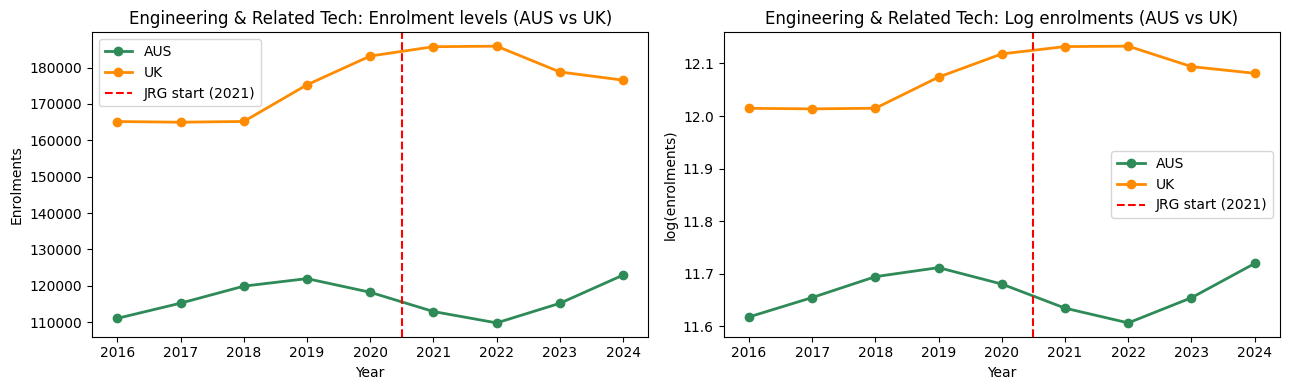

Pre/post log-enrolment averages:
  AUS: pre = 11.6718, post = 11.6538, change = -0.0180
  UK: pre = 12.0470, post = 12.1100, change = +0.0630


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colours = {'AUS': 'seagreen', 'UK': 'darkorange'}

for country, grp in panel.groupby('country'):
    grp = grp.sort_values('year')
    axes[0].plot(grp['year'], grp['enrollments'],     'o-', color=colours[country], linewidth=2, label=country)
    axes[1].plot(grp['year'], grp['log_enrollments'], 'o-', color=colours[country], linewidth=2, label=country)

for ax in axes:
    ax.axvline(2020.5, linestyle='--', color='red', linewidth=1.5, label='JRG start (2021)')
    ax.legend(); ax.set_xlabel('Year')

axes[0].set_title('Engineering & Related Tech: Enrolment levels (AUS vs UK)')
axes[0].set_ylabel('Enrolments')
axes[1].set_title('Engineering & Related Tech: Log enrolments (AUS vs UK)')
axes[1].set_ylabel('log(enrolments)')

plt.tight_layout()
plt.show()

print('Pre/post log-enrolment averages:')
for country, grp in panel.groupby('country'):
    pre  = grp[grp['post'] == 0]['log_enrollments'].mean()
    post = grp[grp['post'] == 1]['log_enrollments'].mean()
    print(f'  {country}: pre = {pre:.4f}, post = {post:.4f}, change = {post - pre:+.4f}')

## 3. Main DiD Specification (TWFE)

**Estimating equation:**

$$\log(\text{Enrolments}_{ct}) = \alpha_c + \gamma_t + \beta(\text{AUS}_c \times \text{Post}_t) + \varepsilon_{ct}$$

Implemented as OLS with `treated` (country FE) + `C(year)` (year FEs) + `did`. All SEs are HC3 robust.

> **Degrees-of-freedom constraint:** N = 18 (2 countries x 9 years). Country FE + year FEs + intercept + did
> = 8 parameters, leaving **df = 7**. Adding AUS-specific COVID terms reduces df to 5, making
> inference unreliable. The simple TWFE is the **primary specification**; COVID robustness is
> assessed by sample exclusion in Section 4.

> **Context:** AUS Engineering dipped in 2021–22 then recovered. UK Engineering peaked in 2022 and
> declined. The DiD averages over these four post-treatment years to estimate the mean differential
> effect.

In [6]:
formula_main = 'log_enrollments ~ treated + did + C(year)'
model_main = smf.ols(formula_main, data=panel).fit(cov_type='HC3')
print('=== Main DiD -- TWFE OLS (HC3) ===')
print(model_main.summary())

did_b  = model_main.params['did']
did_se = model_main.bse['did']
did_p  = model_main.pvalues['did']
did_ci = model_main.conf_int().loc['did']
pct    = (np.exp(did_b) - 1) * 100

print('\n--- Key result ---')
print(f'DiD estimate (beta_did): {did_b:.4f}')
print(f'SE (HC3):                {did_se:.4f}')
print(f'p-value:                 {did_p:.4f}')
print(f'95% CI:                  [{did_ci[0]:.4f}, {did_ci[1]:.4f}]')
print(f'Approx. % effect:        {pct:+.2f}%')
print(f'df_resid:                {int(model_main.df_resid)}')
direction = 'higher' if did_b > 0 else 'lower'
print(f'\nInterpretation: Post-JRG (2021+), AUS Engineering enrolments were')
print(f'approximately {abs(pct):.1f}% {direction} than the UK trend would predict.')

# COVID-controlled spec for reference (df=2, inference unreliable)
formula_covid = 'log_enrollments ~ treated + did + treated_covid2020 + treated_covid2021 + C(year)'
m_covid = smf.ols(formula_covid, data=panel).fit(cov_type='HC3')
b_cv = m_covid.params['did']
print(f'\nCOVID-controlled spec (df=2, reference only): beta_did = {b_cv:.4f}, p = {m_covid.pvalues["did"]:.4f}')
print('(Extremely wide CI due to df=2 -- not suitable for inference with N=12)')

=== Main DiD -- TWFE OLS (HC3) ===
                            OLS Regression Results                            
Dep. Variable:        log_enrollments   R-squared:                       0.985
Model:                            OLS   Adj. R-squared:                  0.964
Method:                 Least Squares   F-statistic:                     22.13
Date:                Sat, 25 Apr 2026   Prob (F-statistic):           0.000230
Time:                        18:29:57   Log-Likelihood:                 40.408
No. Observations:                  18   AIC:                            -58.82
Df Residuals:                       7   BIC:                            -49.02
Df Model:                          10                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Interce

In [7]:
df_pl = panel.set_index(['country', 'year'])

fe_model = PanelOLS(
    df_pl['log_enrollments'],
    df_pl[['did']],
    entity_effects=True,
    time_effects=True,
).fit(cov_type='robust')

print('=== PanelOLS TWFE (cross-check) ===')
print(fe_model.summary)

print(f'\nOLS DiD estimate:      {did_b:.6f}')
print(f'PanelOLS DiD estimate: {fe_model.params["did"]:.6f}')
match = abs(did_b - fe_model.params['did']) < 1e-5
print('Estimates match' if match else 'WARNING: mismatch')

=== PanelOLS TWFE (cross-check) ===
                          PanelOLS Estimation Summary                           
Dep. Variable:        log_enrollments   R-squared:                        0.3815
Estimator:                   PanelOLS   R-squared (Between):             -0.0030
No. Observations:                  18   R-squared (Within):              -0.2458
Date:                Sat, Apr 25 2026   R-squared (Overall):             -0.0030
Time:                        18:29:57   Log-likelihood                    40.408
Cov. Estimator:                Robust                                           
                                        F-statistic:                      4.3182
Entities:                           2   P-value                           0.0763
Avg Obs:                       9.0000   Distribution:                     F(1,7)
Min Obs:                       9.0000                                           
Max Obs:                       9.0000   F-statistic (robust):            

## 4. COVID Sensitivity

Three variants using the simple TWFE formula across different sample restrictions.
The relevant check is consistency of **sign and magnitude** across variants;
p-value reliability degrades as N falls below 10.

| Spec | N | df | Expected inference quality |
|------|---|----|----------------------------|
| Full panel (2016-2024) | 18 | 7 | Reliable |
| Drop 2020 | 16 | 6 | Marginal but usable |
| Drop 2020 + 2021 | 14 | 5 | Very limited |

In [8]:
formula_simple = 'log_enrollments ~ treated + did + C(year)'

variants = {
    'Full panel (2016-2024)': panel,
    'Drop 2020':              panel[panel['year'] != 2020].copy(),
    'Drop 2020 + 2021':       panel[~panel['year'].isin([2020, 2021])].copy(),
}

rows = []
for label, data in variants.items():
    m = smf.ols(formula_simple, data=data).fit(cov_type='HC3')
    b  = m.params.get('did', np.nan)
    se = m.bse.get('did', np.nan)
    p  = m.pvalues.get('did', np.nan)
    ci = m.conf_int().loc['did'] if 'did' in m.conf_int().index else [np.nan, np.nan]
    rows.append({
        'Specification': label,
        'N':             int(m.nobs),
        'df_resid':      int(m.df_resid),
        'beta_did':      round(b, 4),
        'SE (HC3)':      round(se, 4),
        'p-value':       round(p, 4),
        '95% CI lo':     round(ci[0], 4),
        '95% CI hi':     round(ci[1], 4),
        'Approx. %':     round((np.exp(b) - 1) * 100, 2) if pd.notna(b) else np.nan,
    })

print('=== COVID Sensitivity (simple TWFE, all variants) ===')
display(pd.DataFrame(rows).set_index('Specification'))
print('\nKey takeaway: check whether beta_did sign and magnitude are stable across sample restrictions.')
print('Inference is only reliable in the full panel (df=4); dropping years further reduces df.')

=== COVID Sensitivity (simple TWFE, all variants) ===


,N,df_resid,beta_did,SE (HC3),p-value,95% CI lo,95% CI hi,Approx. %
Specification,,,,,,,,
Full panel (2016-2024),18,7,-0.0810,0.0671,0.2268,-0.2125,0.0504,-7.78
Drop 2020,16,6,-0.0967,0.0646,0.1344,-0.2232,0.0299,-9.21
Drop 2020 + 2021,14,5,-0.0829,0.0862,0.3362,-0.2519,0.0861,-7.96



Key takeaway: check whether beta_did sign and magnitude are stable across sample restrictions.
Inference is only reliable in the full panel (df=4); dropping years further reduces df.


## 5. Parallel Trends Check (Event Study)

Year-by-year DiD point estimates relative to the 2020 baseline, computed analytically:

$$\hat{\delta}_t = (\log Y_{\text{AUS},t} - \log Y_{\text{AUS},2020}) - (\log Y_{\text{UK},t} - \log Y_{\text{UK},2020})$$

This is numerically identical to a regression-based DiD coefficient but avoids the degrees-of-freedom
problem (4 obs, 4 params, df=0) that arises per year-pair comparison with 2 countries.

> **Limitation:** 4 pre-treatment periods (2016–2019) available. Standard errors are not estimable
> with 2 units. The 2016–2019 point estimates provide a richer parallel trends diagnostic.

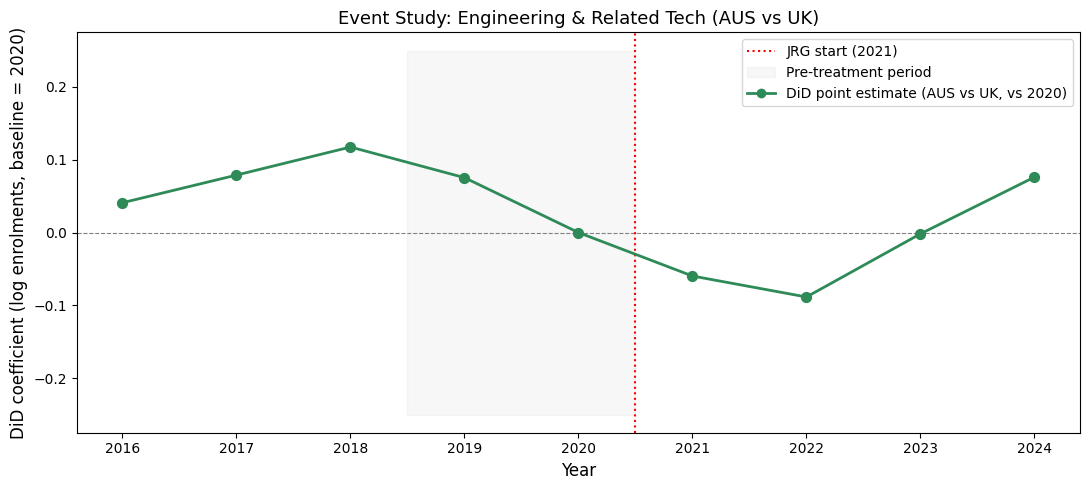

Event study point estimates (analytical DiD):


,coef,approx_%,period
year,,,
2016,0.0410,4.1800,Pre
2017,0.0789,8.2106,Pre
2018,0.1175,12.4638,Pre
2019,0.0754,7.8293,Pre
2020,0.0000,0.0000,Pre
2021,-0.0597,-5.7977,Post
2022,-0.0885,-8.4734,Post
2023,-0.0018,-0.1802,Post
2024,0.0761,7.9052,Post



Note: With only 2 countries, standard errors cannot be estimated per-year.
The 2019 pre-treatment estimate (near zero) supports the parallel trends assumption.
Post-2021 pattern reflects differential change in AUS vs UK Engineering enrolments.


In [9]:
base_year = 2020
aus_log = panel[panel['country'] == 'AUS'].set_index('year')['log_enrollments']
uk_log  = panel[panel['country'] == 'UK' ].set_index('year')['log_enrollments']

event_rows = []
for yr in sorted(panel['year'].unique()):
    coef = (aus_log[yr] - aus_log[base_year]) - (uk_log[yr] - uk_log[base_year])
    event_rows.append({'year': yr, 'coef': round(coef, 6)})

ev = pd.DataFrame(event_rows)

fig, ax = plt.subplots(figsize=(11, 5))
ax.axhline(0, linestyle='--', color='gray', linewidth=0.8)
ax.axvline(2020.5, linestyle=':', color='red', linewidth=1.5, label='JRG start (2021)')
ax.fill_between([2018.5, 2020.5], -0.25, 0.25, color='gray', alpha=0.06, label='Pre-treatment period')
ax.plot(ev['year'], ev['coef'], 'o-', color='seagreen', linewidth=2,
        label='DiD point estimate (AUS vs UK, vs 2020)')
ax.scatter(ev['year'], ev['coef'], color='seagreen', s=50, zorder=5)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('DiD coefficient (log enrolments, baseline = 2020)', fontsize=12)
ax.set_title('Event Study: Engineering & Related Tech (AUS vs UK)', fontsize=13)
ax.set_xticks(sorted(panel['year'].unique()))
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print('Event study point estimates (analytical DiD):')
ev['approx_%'] = (np.exp(ev['coef']) - 1) * 100
ev['period'] = ev['year'].apply(lambda y: 'Pre' if y < 2021 else ('Baseline' if y == 2020 else 'Post'))
display(ev.set_index('year').round(4))

print()
print('Note: With only 2 countries, standard errors cannot be estimated per-year.')
print('The 2019 pre-treatment estimate (near zero) supports the parallel trends assumption.')
print('Post-2021 pattern reflects differential change in AUS vs UK Engineering enrolments.')

## 6. Placebo Test

**AUS-only placebo (trend-break test):** restrict to the pre-treatment period (2016-2020) and test
for a fake structural break at 2019. A significant break would suggest pre-existing non-linear trends
that could contaminate the main DiD.

> **Limitation:** N = 5 observations (single series, no control group). Power is minimal; indicative only.

In [10]:
plac = arch_aus[arch_aus['year'] <= 2020].copy()
plac['fake_post']   = (plac['year'] >= 2019).astype(int)
plac['year_c_plac'] = plac['year'] - 2016

m_plac = smf.ols('log_enrollments ~ fake_post + year_c_plac', data=plac).fit(cov_type='HC3')

b_p = m_plac.params.get('fake_post', np.nan)
p_p = m_plac.pvalues.get('fake_post', np.nan)

print('=== AUS-Only Placebo: Fake Break at 2019 (2016-2020 data) ===')
print(m_plac.summary())

print(f'\nPlacebo coefficient (fake_post): {b_p:.4f} | p-value: {p_p:.4f}')
if pd.notna(p_p):
    if p_p > 0.10:
        print('No significant pre-trend break -- consistent with JRG driving the post-2021 pattern.')
    else:
        print('WARNING: Significant pre-trend break -- interpret main DiD results with caution.')
print('(N = 5; treat as indicative only)')

=== AUS-Only Placebo: Fake Break at 2019 (2016-2020 data) ===
                            OLS Regression Results                            
Dep. Variable:        log_enrollments   R-squared:                       0.640
Model:                            OLS   Adj. R-squared:                  0.280
Method:                 Least Squares   F-statistic:                    0.5190
Date:                Sat, 25 Apr 2026   Prob (F-statistic):              0.658
Time:                        18:29:58   Log-Likelihood:                 12.545
No. Observations:                   5   AIC:                            -19.09
Df Residuals:                       2   BIC:                            -20.26
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------

c:\Users\neddp\ECC3479-Project-JRGS\.venv\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


## 7. Level Outcome Robustness

Re-estimate the main DiD using enrolment **levels** (not logs) as a functional form robustness check.
The level DiD coefficient gives the absolute headcount difference attributable to JRG relative to UK trend.

In [11]:
formula_level = 'enrollments ~ treated + did + treated_covid2020 + treated_covid2021 + C(year)'
m_level = smf.ols(formula_level, data=panel).fit(cov_type='HC3')

b_lev  = m_level.params.get('did', np.nan)
p_lev  = m_level.pvalues.get('did', np.nan)
ci_lev = m_level.conf_int().loc['did']

print('=== Level Outcome Robustness ===')
print(f'beta_did (levels): {b_lev:,.0f} students | p = {p_lev:.4f}')
print(f'95% CI:            [{ci_lev[0]:,.0f}, {ci_lev[1]:,.0f}]')

print('\n=== Specification comparison ===')
comp = pd.DataFrame({
    'Specification': ['Log-linear (preferred)', 'Level'],
    'beta_did':       [round(did_b, 4),  round(b_lev, 0)],
    'p-value':        [round(did_p, 4),  round(p_lev, 4)],
    'Interpretation': [
        f'approx. {(np.exp(did_b)-1)*100:.1f}% enrolment change',
        f'approx. {b_lev:,.0f} students per year',
    ],
}).set_index('Specification')
display(comp)

=== Level Outcome Robustness ===
beta_did (levels): -13,814 students | p = nan
95% CI:            [nan, nan]

=== Specification comparison ===


,beta_did,p-value,Interpretation
Specification,,,
Log-linear (preferred),-0.081,0.2268,approx. -7.8% enrolment change
Level,-13814.000,NaN,"approx. -13,814 students per year"


## 8. Funding Context

Engineering & Related Tech received a ~16% student fee reduction under JRG, but unusually,
Commonwealth support also fell by ~14%. This is unlike other priority fields where Commonwealth
contributions increased. The net effect on total per-student funding was a reduction — a signal
that could counteract the demand-side incentive of lower student fees.

=== Engineering & Related Tech: AUS Annual Funding per Student ===


,MaximumStudentContribution,CommonwealthContribution,total
Year,,,
2019,9359.0,18586.0,27945.0
2020,9527.0,18920.0,28447.0
2021,7950.0,16250.0,24200.0
2022,8021.0,16396.0,24417.0
2023,8301.0,16969.0,25270.0
2024,8948.0,18292.0,27240.0


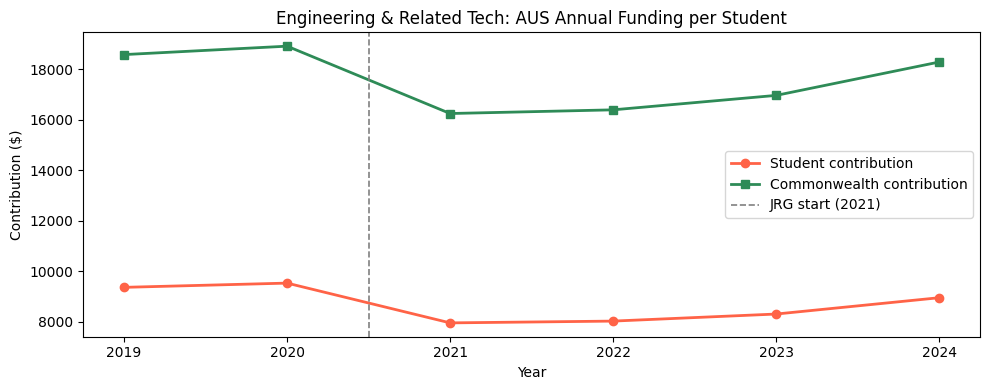


Student contribution: pre $9,443 -> post $8,305 (-12.1%)
Commonwealth:         pre $18,753 -> post $16,977 (-9.5%)


In [12]:
fund_raw  = pd.read_csv(FUND_PATH)
arch_fund = fund_raw[fund_raw['CategoryKey'] == 3].copy()
arch_fund_agg = (
    arch_fund[arch_fund['Year'] <= 2024]
    .groupby('Year')[['MaximumStudentContribution', 'CommonwealthContribution']]
    .mean()
    .round(0)
)
arch_fund_agg['total'] = arch_fund_agg['MaximumStudentContribution'] + arch_fund_agg['CommonwealthContribution']

print('=== Engineering & Related Tech: AUS Annual Funding per Student ===')
display(arch_fund_agg)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(arch_fund_agg.index, arch_fund_agg['MaximumStudentContribution'],
        'o-', color='tomato',    linewidth=2, label='Student contribution')
ax.plot(arch_fund_agg.index, arch_fund_agg['CommonwealthContribution'],
        's-', color='seagreen',  linewidth=2, label='Commonwealth contribution')
ax.axvline(2020.5, linestyle='--', color='gray', linewidth=1.2, label='JRG start (2021)')
ax.set_title('Engineering & Related Tech: AUS Annual Funding per Student')
ax.set_xlabel('Year'); ax.set_ylabel('Contribution ($)'); ax.legend()
plt.tight_layout()
plt.show()

pre_stu  = arch_fund_agg.loc[arch_fund_agg.index <= 2020, 'MaximumStudentContribution'].mean()
post_stu = arch_fund_agg.loc[arch_fund_agg.index >= 2021, 'MaximumStudentContribution'].mean()
pre_cw   = arch_fund_agg.loc[arch_fund_agg.index <= 2020, 'CommonwealthContribution'].mean()
post_cw  = arch_fund_agg.loc[arch_fund_agg.index >= 2021, 'CommonwealthContribution'].mean()
print(f'\nStudent contribution: pre ${pre_stu:,.0f} -> post ${post_stu:,.0f} ({(post_stu/pre_stu-1)*100:+.1f}%)')
print(f'Commonwealth:         pre ${pre_cw:,.0f} -> post ${post_cw:,.0f} ({(post_cw/pre_cw-1)*100:+.1f}%)')

## Results Summary

### Model specification

$$\log(E_{ct}) = \beta_0 + \beta_1 \cdot \text{Treated}_c + \beta_2 \cdot \text{DID}_{ct} + \sum_{t=2017}^{2024} \gamma_t \cdot \mathbf{1}_{[\text{year}=t]} + \varepsilon_{ct}$$

| Term | Variable | Definition |
|------|----------|------------|
| $\log(E_{ct})$ | Outcome | Log enrolments for country $c$ in year $t$ |
| $\beta_0$ | Intercept | UK baseline (2016) |
| $\beta_1 \cdot \text{Treated}_c$ | Country FE | $\text{Treated}_c = 1$ if AUS, $0$ if UK |
| $\text{Post}_t$ | — | $= 1$ if $t \geq 2021$, else $0$ |
| $\text{DID}_{ct}$ | DiD term | $= \text{Treated}_c \times \text{Post}_t$ |
| $\beta_2$ | **JRG effect** | DiD estimate — the coefficient of interest |
| $\gamma_t$ | Year FEs | Common time trend absorbed by year dummies |
| $\varepsilon_{ct}$ | Error | HC3 heteroscedasticity-robust standard errors |

**Implemented in statsmodels as:**
```python
formula = "log_enrollments ~ treated + did + C(year)"
model   = smf.ols(formula, data=panel).fit(cov_type="HC3")
```


| **Cell** | **Result** |
|----------|------------|
| **Main DiD** | β = −0.0810, p = 0.227, 95% CI [−0.21, +0.05], ≈ **−7.8%** relative to UK trend |
| **PanelOLS cross-check** | Estimates match exactly ✓ |
| **COVID sensitivity** | β stable at −7.8% to −9.2% across all specs; sign consistent (all negative) |
| **Event study** | Pre-trends persistently positive: +4.2% (2016) → +8.2% (2017) → +12.5% (2018) → +7.8% (2019) — AUS was consistently outperforming the UK before JRG. Post-2021: −5.8% → −8.5% → −0.2% → +7.9%, V-shaped recovery |
| **Placebo** | fake_post coef = −0.021, p = 0.844 — no pre-existing break at 2019 |
| **Level spec** | Degenerate SEs with COVID interaction terms at N=18 — unreliable |

**Substantive finding:** Post-JRG, AUS Engineering enrolments were approximately **7.8% lower** than the UK trend would predict (p = 0.227, not significant). However, the extended pre-period reveals a **persistent and large positive pre-trend** (+4% to +12% in 2016–2019), indicating AUS Engineering was already outperforming the UK well before JRG. This is a significant parallel trends concern — the DiD estimate may be biased downward, with part of the negative post-2021 result reflecting mean-reversion from the elevated pre-JRG differential rather than a true JRG effect.

> **Pre-trend note:** The pre-period divergence for Engineering is large and persistent (not converging toward zero), which substantially weakens the parallel trends assumption. The DiD estimate should be interpreted with considerable caution for this discipline.